In [ ]:
!pip install scanpy
!pip install anndata
!pip3 install igraph
!pip install celltypist
!pip install decoupler
!pip install fa2-modified
!pip install louvain
!pip install pertpy

In [ ]:
#Import core single cell datasets

import scanpy as sc
import anndata as ad
import numpy as np
import pertpy as pt

In [ ]:
#!wget https://datasets.cellxgene.cziscience.com/fdf57c52-ad71-4004-9db2-a962e849b524.h5ad
!wget https://datasets.cellxgene.cziscience.com/497ab773-4fd5-4263-9fdf-7b42a68f1351.h5ad

--2025-10-28 16:03:05--  https://datasets.cellxgene.cziscience.com/497ab773-4fd5-4263-9fdf-7b42a68f1351.h5ad
Resolving datasets.cellxgene.cziscience.com (datasets.cellxgene.cziscience.com)... 13.35.185.126, 13.35.185.84, 13.35.185.112, ...
Connecting to datasets.cellxgene.cziscience.com (datasets.cellxgene.cziscience.com)|13.35.185.126|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 74549927 (71M) [binary/octet-stream]
Saving to: ‘497ab773-4fd5-4263-9fdf-7b42a68f1351.h5ad.1’

497ab773-4fd5-4263- 100%[===================>]  71.10M  97.2MB/s    in 0.7s    

2025-10-28 16:03:06 (97.2 MB/s) - ‘497ab773-4fd5-4263-9fdf-7b42a68f1351.h5ad.1’ saved [74549927/74549927]



In [ ]:
bm_mtx = sc.read_h5ad('/content/497ab773-4fd5-4263-9fdf-7b42a68f1351.h5ad')
bm_mtx.var_names_make_unique()

In [ ]:
bm_mtx.shape

(14783, 17374)

In [ ]:
# A useful step for older datasets
bm_mtx.var_names_make_unique()
bm_mtx.obs_names_make_unique()

In [ ]:
bm_mtx.var.head()

,n_cells,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type
ENSG00000161920,927,False,MED11,NCBITaxon:9606,gene,754,protein_coding
ENSG00000122335,429,False,SERAC1,NCBITaxon:9606,gene,2683,protein_coding
ENSG00000175548,149,False,ALG10B,NCBITaxon:9606,gene,1773,protein_coding
ENSG00000100330,426,False,MTMR3,NCBITaxon:9606,gene,634,protein_coding
ENSG00000176340,7171,False,COX8A,NCBITaxon:9606,gene,494,protein_coding


In [ ]:
bm_mtx.shape

(14783, 17374)

In [ ]:
bm_mtx.var['MT'] = bm_mtx.var_names.str.startswith("MT-")
bm_mtx.var['RIBO'] = bm_mtx.var_names.str.startswith("RPS", "RPL")
bm_mtx.var['HB'] = bm_mtx.var_names.str.startswith("^HB[^(P)]")

In [ ]:
sc.pp.calculate_qc_metrics(
    bm_mtx, qc_vars=["MT", 'RIBO', 'HB'], inplace=True, log1p=True
)

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (5,4)  # Adjust figure size
plt.rcParams["axes.grid"] = True  # Add grid to plots
plt.rcParams["axes.edgecolor"] = "black" # Set plot border color
plt.rcParams["axes.linewidth"] = 1.5 # Set plot border width
plt.rcParams["axes.facecolor"] = "white" # Set background color
plt.rcParams["axes.labelcolor"] = "black" # Set label color
plt.rcParams["xtick.color"] = "black" # Set x-axis tick color
plt.rcParams["ytick.color"] = "black" # Set y-axis tick color
plt.rcParams["text.color"] = "black" # Set text color
%matplotlib inline

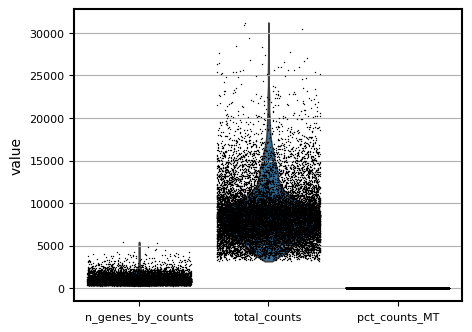

In [ ]:
sc.pl.violin(
    bm_mtx,
    ["n_genes_by_counts", 'total_counts', 'pct_counts_MT'],
    jitter=0.4,
    multi_panel=False,
)



In [ ]:
bm_mtx.obs_keys()

/tmp/ipython-input-3505303993.py:1: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  bm_mtx.obs_keys()


['disease stage',
 'treatment',
 'timepoint',
 'Dataset',
 'sample',
 'disease_original',
 'disease_general',
 'COVID-19 Condition',
 'Lineage',
 'Cell.group',
 'Cell.class_reannotated',
 'n_genes',
 'n_counts',
 'percent_mito',
 'tissue_original',
 'tissue_ontology_term_id',
 'disease_ontology_term_id',
 'donor_id',
 'development_stage_ontology_term_id',
 'assay_ontology_term_id',
 'cell_type_ontology_term_id',
 'self_reported_ethnicity_ontology_term_id',
 'sex_ontology_term_id',
 'is_primary_data',
 'suspension_type',
 'tissue_type',
 'cell_type',
 'assay',
 'disease',
 'sex',
 'tissue',
 'self_reported_ethnicity',
 'development_stage',
 'observation_joinid',
 'n_genes_by_counts',
 'log1p_n_genes_by_counts',
 'total_counts',
 'log1p_total_counts',
 'pct_counts_in_top_50_genes',
 'pct_counts_in_top_100_genes',
 'pct_counts_in_top_200_genes',
 'pct_counts_in_top_500_genes',
 'total_counts_MT',
 'log1p_total_counts_MT',
 'pct_counts_MT',
 'total_counts_RIBO',
 'log1p_total_counts_RIBO',

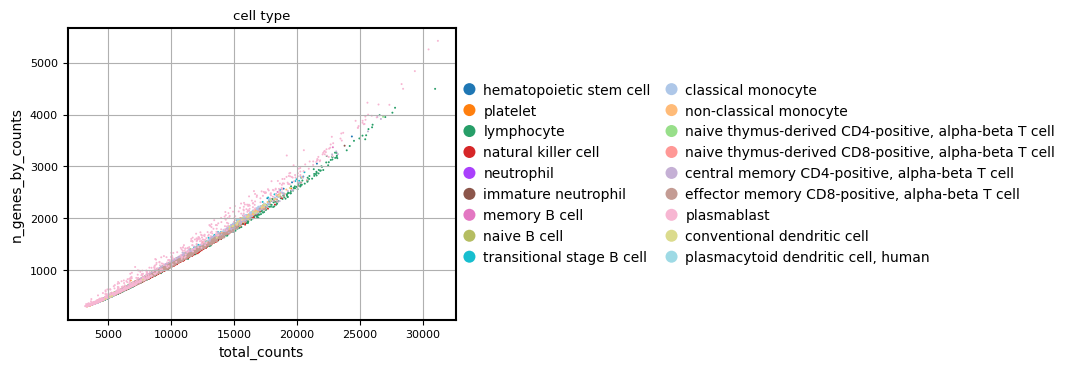

In [ ]:
sc.pl.scatter(bm_mtx, "total_counts", "n_genes_by_counts", color="cell_type")

In [ ]:
#sc.pp.scrublet(bm_mtx)

In [ ]:
#Normalisation
bm_mtx.layers["counts"] = bm_mtx.X.copy()
sc.pp.normalize_total(bm_mtx)
sc.pp.log1p(bm_mtx)

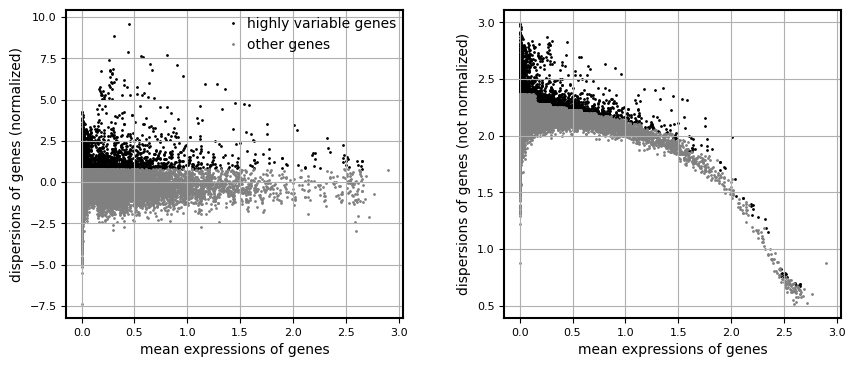

In [ ]:
#Feature selection
sc.pp.highly_variable_genes(bm_mtx, n_top_genes=2500)
sc.pl.highly_variable_genes(bm_mtx)

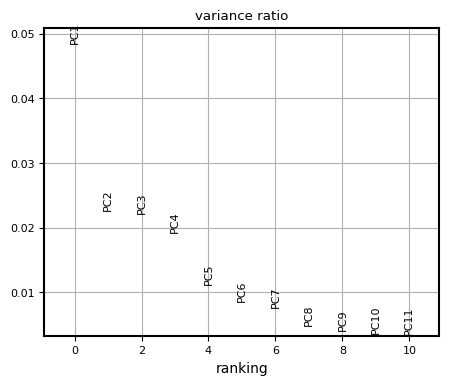

In [ ]:
#Dim Reduction
sc.tl.pca(bm_mtx)
sc.pl.pca_variance_ratio(bm_mtx, n_pcs=10, log=False)


In [ ]:
bm_mtx.var_names

Index(['ENSG00000161920', 'ENSG00000122335', 'ENSG00000175548',
       'ENSG00000100330', 'ENSG00000176340', 'ENSG00000179846',
       'ENSG00000204860', 'ENSG00000172260', 'ENSG00000141424',
       'ENSG00000164512',
       ...
       'ENSG00000164114', 'ENSG00000151702', 'ENSG00000224578',
       'ENSG00000138756', 'ENSG00000111052', 'ENSG00000176946',
       'ENSG00000150456', 'ENSG00000284934', 'ENSG00000261842',
       'ENSG00000260456'],
      dtype='object', length=17374)

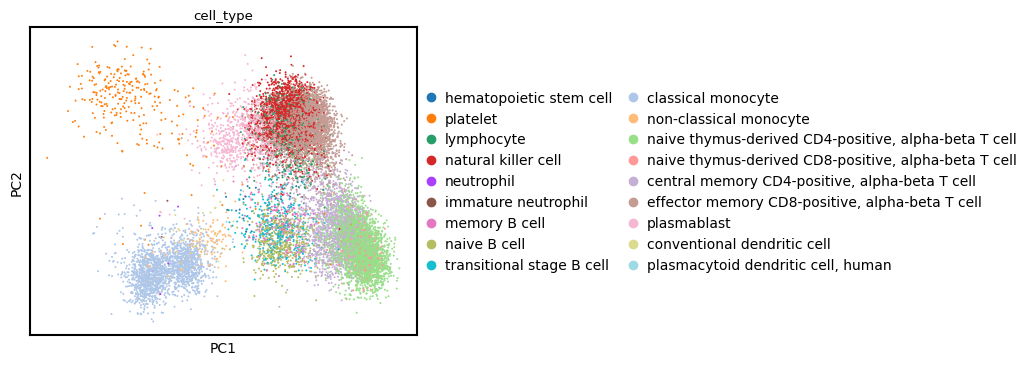

In [ ]:
sc.pl.pca(bm_mtx, color=["cell_type"], cmap="coolwarm")

In [ ]:
sc.pp.neighbors(bm_mtx)
sc.tl.umap(bm_mtx)

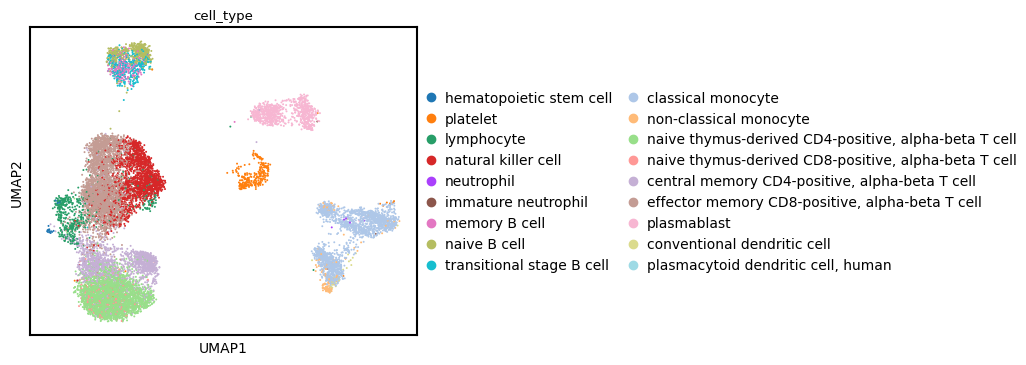

In [ ]:
sc.pl.umap(
    bm_mtx,
    color=["cell_type"],
    size=8,
)

In [ ]:
sc.tl.leiden(bm_mtx, flavor="igraph", n_iterations=10, key_added="leiden_res_", resolution=0.5 )

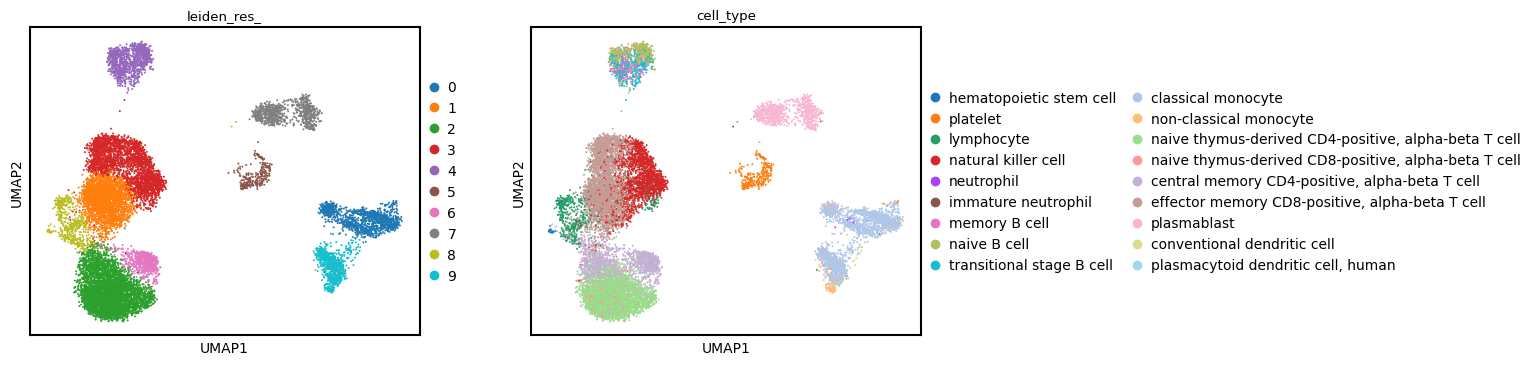

In [ ]:
sc.pl.umap(
    bm_mtx,
    color=["leiden_res_", 'cell_type'],
    size=8,
)

In [ ]:
import decoupler as dc

In [ ]:
!wget wget -O result.txt 'http://www.ensembl.org/biomart/martservice?query=<?xml version="1.0" encoding="UTF-8"?><!DOCTYPE Query><Query  virtualSchemaName = "default" formatter = "CSV" header = "0" uniqueRows = "0" count = "" datasetConfigVersion = "0.6" ><Dataset name = "hsapiens_gene_ensembl" interface = "default" ><Attribute name = "ensembl_gene_id" /><Attribute name = "external_gene_name" /></Dataset></Query>'

--2025-10-28 16:03:51--  http://wget/
Resolving wget (wget)... failed: Name or service not known.
wget: unable to resolve host address ‘wget’
--2025-10-28 16:03:51--  http://www.ensembl.org/biomart/martservice?query=%3C?xml%20version=%221.0%22%20encoding=%22UTF-8%22?%3E%3C!DOCTYPE%20Query%3E%3CQuery%20%20virtualSchemaName%20=%20%22default%22%20formatter%20=%20%22CSV%22%20header%20=%20%220%22%20uniqueRows%20=%20%220%22%20count%20=%20%22%22%20datasetConfigVersion%20=%20%220.6%22%20%3E%3CDataset%20name%20=%20%22hsapiens_gene_ensembl%22%20interface%20=%20%22default%22%20%3E%3CAttribute%20name%20=%20%22ensembl_gene_id%22%20/%3E%3CAttribute%20name%20=%20%22external_gene_name%22%20/%3E%3C/Dataset%3E%3C/Query%3E
Resolving www.ensembl.org (www.ensembl.org)... 193.62.193.83
Connecting to www.ensembl.org (www.ensembl.org)|193.62.193.83|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/plain]
Saving to: ‘result.txt’

result.txt              [          <=>  

In [ ]:
import pandas as pd

ensembl_var = pd.read_csv('/content/result.txt', header = None)

ensembl_var.columns = ['ensembl_gene_id', 'gene_name']

ensembl_var.head(3)

,ensembl_gene_id,gene_name
0,ENSG00000210049,MT-TF
1,ENSG00000211459,MT-RNR1
2,ENSG00000210077,MT-TV


In [ ]:
# Query Omnipath and get PanglaoDB
markers = dc.op.resource(name="PanglaoDB", organism="human")

# Keep canonical cell type markers alone
markers = markers[markers["canonical_marker"]]

# Remove duplicated entries
markers = markers[~markers.duplicated(["cell_type", "genesymbol"])]

#Format because dc only accepts cell_type and genesymbol

markers = markers.rename(columns={"cell_type": "source", "genesymbol": "target"})
markers = markers[["source", "target"]]


markers.head()

,source,target
,,
2,Bergmann glia,A2M
4,Mast cells,A4GALT
5,Embryonic stem cells,A7KBS4
8,Pinealocytes,AANAT
9,Astrocytes,AANAT


In [ ]:
#correct target to ensemble
markers = markers.merge(ensembl_var, left_on="target", right_on="gene_name", how="left")
markers = markers.drop(columns=["target"])
# Remove duplicated entries
markers = markers[~markers.duplicated(["source", "ensembl_gene_id"])]

#Format because dc only accepts cell_type and genesymbol
markers = markers.rename(columns={"source": "source", "ensembl_gene_id": "target"})

markers = markers[["source", "target"]]
markers = markers.dropna()

markers.head()

,source,target
0,Bergmann glia,ENSG00000175899
1,Mast cells,ENSG00000128274
3,Pinealocytes,ENSG00000129673
4,Astrocytes,ENSG00000129673
5,Sertoli cells,ENSG00000205002


In [ ]:
bm_mtx.var_names

Index(['ENSG00000161920', 'ENSG00000122335', 'ENSG00000175548',
       'ENSG00000100330', 'ENSG00000176340', 'ENSG00000179846',
       'ENSG00000204860', 'ENSG00000172260', 'ENSG00000141424',
       'ENSG00000164512',
       ...
       'ENSG00000164114', 'ENSG00000151702', 'ENSG00000224578',
       'ENSG00000138756', 'ENSG00000111052', 'ENSG00000176946',
       'ENSG00000150456', 'ENSG00000284934', 'ENSG00000261842',
       'ENSG00000260456'],
      dtype='object', length=17374)

In [ ]:
dc.mt.ulm(data=bm_mtx,
          net=markers,
          tmin = 3)

In [ ]:
score = dc.pp.get_obsm(bm_mtx, key="score_ulm")

In [ ]:
bm_mtx.obsm["score_ulm"].head(1)

,Acinar cells,Adipocytes,Adrenergic neurons,Airway goblet cells,Alpha cells,Alveolar macrophages,Astrocytes,B cells,B cells memory,B cells naive,...,T follicular helper cells,T helper cells,T memory cells,T regulatory cells,Tanycytes,Taste receptor cells,Thymocytes,Trophoblast cells,Tuft cells,Urothelial cells
index,,,,,,,,,,,,,,,,,,,,,
Guo-AAACCTGAGAGCTTCT-2,0.883366,0.01644,-0.592726,-0.662709,0.83584,0.855729,0.297566,1.485696,-0.306571,0.23799,...,-0.5133,-0.422886,1.642851,-0.004406,0.544296,0.413771,-0.543441,-0.5133,3.11394,-0.784177


In [ ]:
bm_mtx.obsm["score_ulm"].columns

Index(['Acinar cells', 'Adipocytes', 'Adrenergic neurons',
       'Airway goblet cells', 'Alpha cells', 'Alveolar macrophages',
       'Astrocytes', 'B cells', 'B cells memory', 'B cells naive',
       ...
       'T follicular helper cells', 'T helper cells', 'T memory cells',
       'T regulatory cells', 'Tanycytes', 'Taste receptor cells', 'Thymocytes',
       'Trophoblast cells', 'Tuft cells', 'Urothelial cells'],
      dtype='object', length=126)

In [ ]:
#rank genes
bm_gene_rank = dc.tl.rankby_group(score, groupby="leiden_res_", reference="rest", method="t-test_overestim_var")
bm_gene_rank = bm_gene_rank[bm_gene_rank["stat"] > 0]
bm_gene_rank.head(5)

,group,reference,name,stat,meanchange,pval,padj
0,0,rest,Neutrophils,114.411587,6.383910,0.0,0.0
1,0,rest,Macrophages,88.435972,5.630205,0.0,0.0
2,0,rest,Dendritic cells,84.675829,5.373598,0.0,0.0
3,0,rest,Microglia,83.824771,4.274959,0.0,0.0
4,0,rest,Monocytes,80.601857,5.561706,0.0,0.0


In [ ]:
top_names_per_group = bm_gene_rank.groupby('group')['name'].apply(lambda x: x.head(1))
display(top_names_per_group)

/tmp/ipython-input-2279155867.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_names_per_group = bm_gene_rank.groupby('group')['name'].apply(lambda x: x.head(1))


,,name
group,,
0,0,Neutrophils
1,126,NK cells
2,252,Nuocytes
3,378,NK cells
4,504,B cells naive
5,630,Platelets
6,756,Nuocytes
7,882,Plasma cells
8,1023,Gamma delta T cells


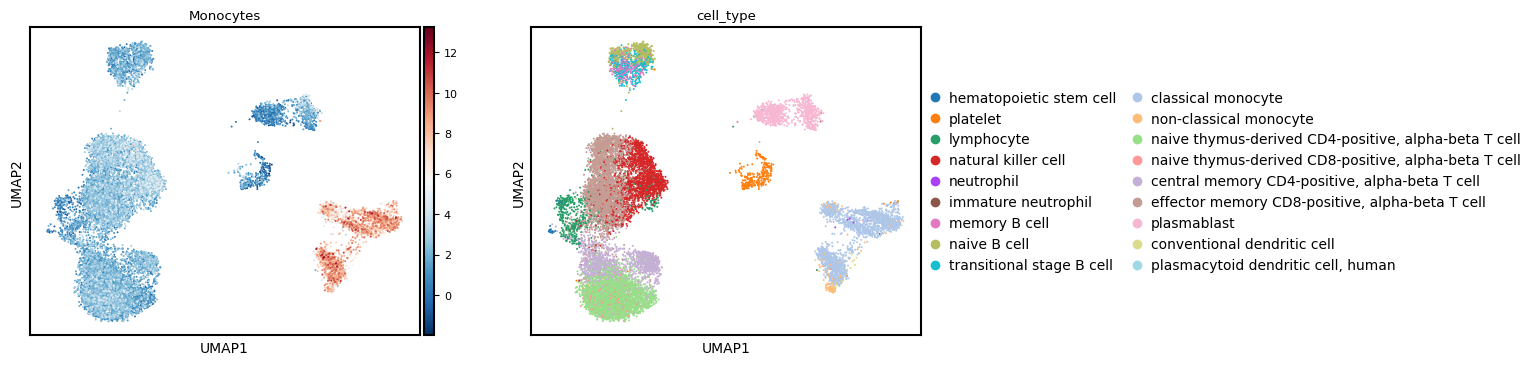

In [ ]:
sc.pl.umap(score, color=["Monocytes","cell_type"], cmap="RdBu_r")

In [ ]:
n_ctypes = 1
ctypes_dict = bm_gene_rank.groupby("group").head(n_ctypes).groupby("group")["name"].apply(lambda x: list(x)).to_dict()
ctypes_dict

/tmp/ipython-input-3463462141.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ctypes_dict = bm_gene_rank.groupby("group").head(n_ctypes).groupby("group")["name"].apply(lambda x: list(x)).to_dict()


{'0': ['Neutrophils'],
 '1': ['NK cells'],
 '2': ['Nuocytes'],
 '3': ['NK cells'],
 '4': ['B cells naive'],
 '5': ['Platelets'],
 '6': ['Nuocytes'],
 '7': ['Plasma cells'],
 '8': ['Gamma delta T cells'],
 '9': ['Monocytes']}

In [ ]:
dict_ann = bm_gene_rank[bm_gene_rank["stat"] > 0].groupby("group").head(1).set_index("group")["name"].to_dict()
dict_ann

/tmp/ipython-input-4239545895.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dict_ann = bm_gene_rank[bm_gene_rank["stat"] > 0].groupby("group").head(1).set_index("group")["name"].to_dict()


{'0': 'Neutrophils',
 '1': 'NK cells',
 '2': 'Nuocytes',
 '3': 'NK cells',
 '4': 'B cells naive',
 '5': 'Platelets',
 '6': 'Nuocytes',
 '7': 'Plasma cells',
 '8': 'Gamma delta T cells',
 '9': 'Monocytes'}

In [ ]:
dict_ann_unique = {k: v + '_' + str(k) for k, v in dict_ann.items()}
display(dict_ann_unique)

{'0': 'Neutrophils_0',
 '1': 'NK cells_1',
 '2': 'Nuocytes_2',
 '3': 'NK cells_3',
 '4': 'B cells naive_4',
 '5': 'Platelets_5',
 '6': 'Nuocytes_6',
 '7': 'Plasma cells_7',
 '8': 'Gamma delta T cells_8',
 '9': 'Monocytes_9'}

In [ ]:
bm_mtx.obs["leiden_res_"] = bm_mtx.obs["leiden_res_"].cat.rename_categories(dict_ann_unique)

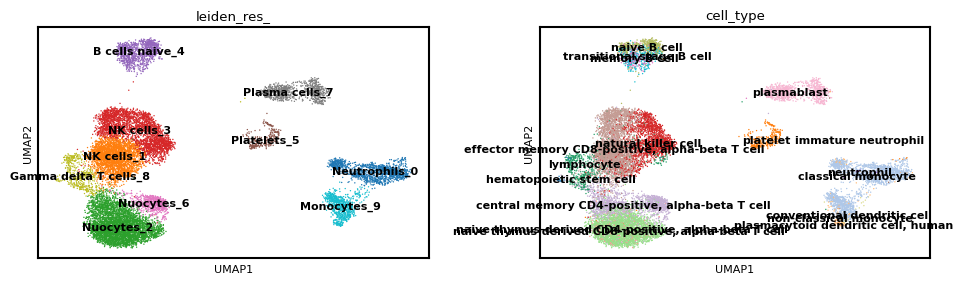

In [ ]:

plt.rcParams["figure.figsize"] = (5,3)  # Adjust figure size
# Reduce the default font size for text elements in plots
plt.rcParams['font.size'] = 8
plt.rcParams['axes.labelsize'] = 8
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8

# Now replot the UMAP
sc.pl.umap(
    adata=bm_mtx,
    color=[ "leiden_res_", 'cell_type'],
    ncols=2,
    legend_loc = 'on data',
    size=4,
)

In [ ]:
#Pseudotime inference
sc.tl.diffmap(bm_mtx)

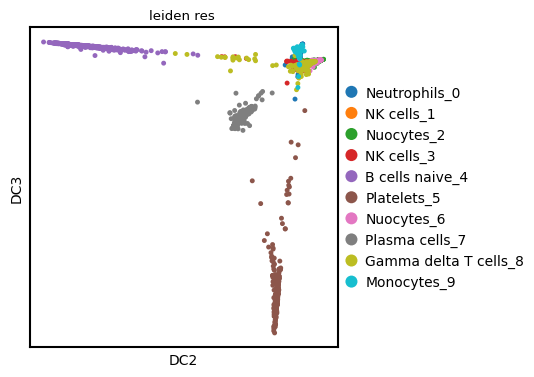

In [ ]:
plt.rcParams["figure.figsize"] = (4,4)
plt.rcParams['axes.labelsize'] = 10

root_ixs = bm_mtx.obsm["X_diffmap"][:, 3].argmin()
sc.pl.scatter(
    bm_mtx,
    basis="diffmap",
    color=["leiden_res_"],
    components=[2, 3],
    size=50
)

bm_mtx.uns["iroot"] = root_ixs

In [ ]:
sc.tl.dpt(bm_mtx)

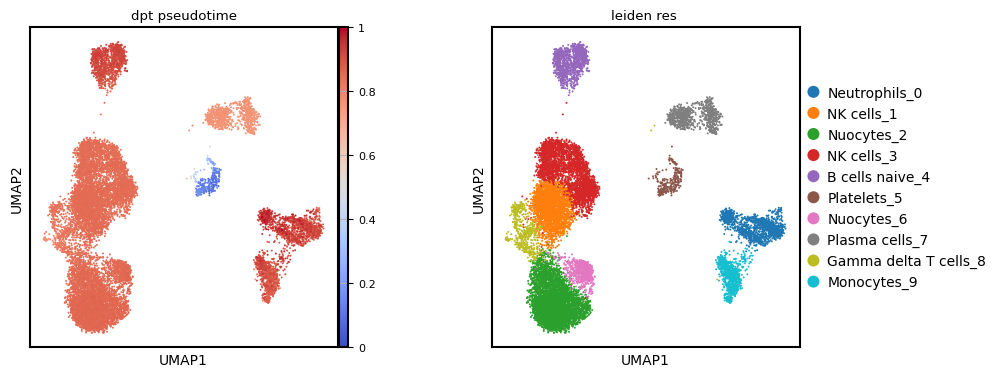

In [ ]:
sc.pl.scatter(
    bm_mtx,
    basis="umap",
    color=["dpt_pseudotime", 'leiden_res_'],
    color_map="coolwarm",
)

In [ ]:
#Trajectory analysis
root_celltype = "Platelets_5"


sc.pp.neighbors(bm_mtx, use_rep="X_diffmap")
sc.tl.paga(bm_mtx, groups="leiden_res_")
iroot = np.flatnonzero(bm_mtx.obs["leiden_res_"] == root_celltype)[0]
bm_mtx.uns["iroot"] = iroot
sc.tl.dpt(bm_mtx)

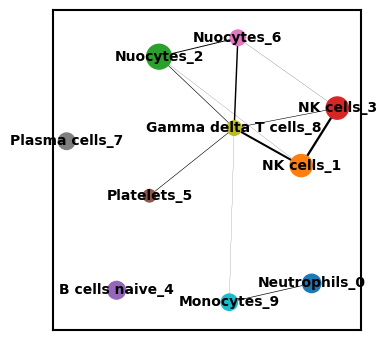

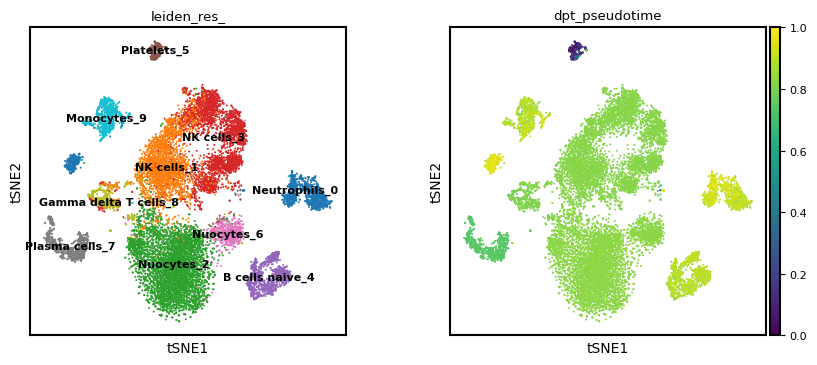

In [ ]:
sc.pl.paga(bm_mtx, color=["leiden_res_"])
sc.pl.tsne(bm_mtx, color=["leiden_res_", "dpt_pseudotime"], legend_loc="on data")

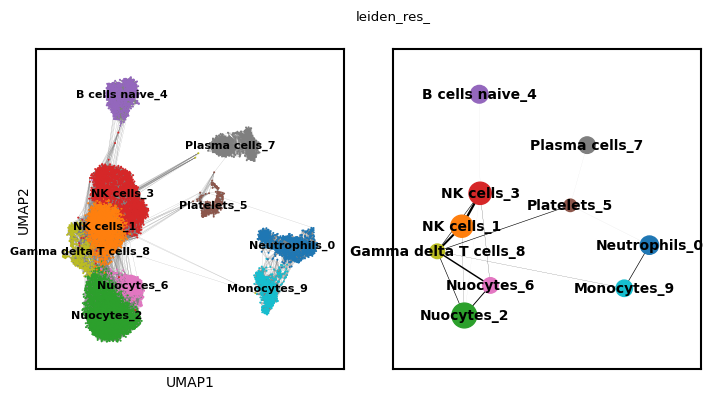

[<Axes: xlabel='UMAP1', ylabel='UMAP2'>, <Axes: >]

In [ ]:
sc.pl.paga_compare(bm_mtx, threshold=0.001, frameon=True, edges=True)

In [ ]:
bm_mtx.uns['iroot'] = np.flatnonzero(bm_mtx.obs['leiden_res_']  == 'Platelets_5')[0]
sc.tl.dpt(bm_mtx)

In [ ]:
bm_mtx

AnnData object with n_obs × n_vars = 14783 × 17374
    obs: 'disease stage', 'treatment', 'timepoint', 'Dataset', 'sample', 'disease_original', 'disease_general', 'COVID-19 Condition', 'Lineage', 'Cell.group', 'Cell.class_reannotated', 'n_genes', 'n_counts', 'percent_mito', 'tissue_original', 'tissue_ontology_term_id', 'disease_ontology_term_id', 'donor_id', 'development_stage_ontology_term_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_MT', 'log1p_total_counts_MT', 'pct_counts_MT', 'total_counts_RIBO', 'log1p_total_

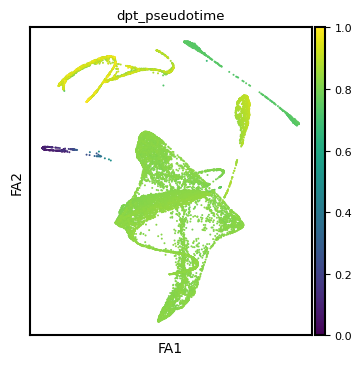

In [ ]:
sc.tl.draw_graph(bm_mtx, layout='fa')
sc.pl.draw_graph(bm_mtx, color=['dpt_pseudotime'], legend_loc='on data')